In [ ]:
import os


In [2]:
from libcbm import resources
from libcbm.model.moss_c import model_context_factory
from libcbm.model.moss_c import model

The moss c pools are defined in a python enumeration, and can be fetched as in the following example

In [3]:
# get the moss C pools
from libcbm.model.moss_c.pools import Pool
for pool in Pool:
    print(pool.name)

Input
FeatherMossLive
SphagnumMossLive
FeatherMossFast
SphagnumMossFast
FeatherMossSlow
SphagnumMossSlow
CO2
CH4
CO
Products


In [4]:
Pool.Input.value

0

Some moss c model test cases, and example datasets are included in the [libcbm test resources dir](https://github.com/cat-cfs/libcbm_py/tree/master/libcbm/resources/test)

In [5]:
test_data_dir = os.path.join(
   resources.get_test_resources_dir(),
    "moss_c_test_case")

Assembling the moss c [model context]()

In [6]:
ctx = model_context_factory.create_from_csv(test_data_dir)

Run the model spinup routine.  The model context will be altered in-place by the spinup process.

Setting enable_debugging=True will make the spinup method return a detailed timestep-by-timestep account of the spinup process, but will incur a significant processing and memory consumption cost.

In [7]:
spinup_debug = model.spinup(ctx, enable_debugging=True)

In [8]:
spinup_vars = spinup_debug.spinup_vars.to_pandas().copy()

In [9]:
display(spinup_vars)

,t,spinup_state,rotation_num,last_rotation_slow,this_rotation_slow
0,0,1,0,0.000000,0.000000
1,1,1,0,0.000000,0.000000
2,2,1,0,0.000000,0.000000
3,3,1,0,0.000000,0.000000
4,4,1,0,0.000000,0.000000
...,...,...,...,...,...
2641,2641,1,20,12.970911,13.016129
2642,2642,1,20,12.970911,13.015564
2643,2643,1,20,12.970911,13.015086
2644,2644,1,20,12.970911,13.014695


<Axes: xlabel='t'>

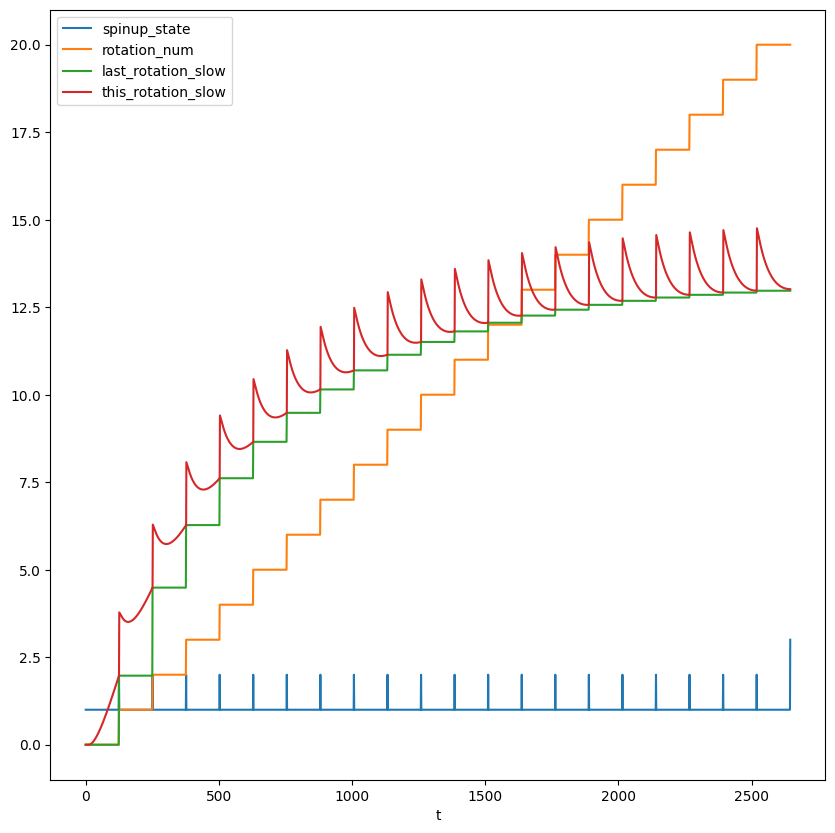

In [10]:
spinup_vars.set_index("t").plot(figsize=(10,10))

<Axes: xlabel='t'>

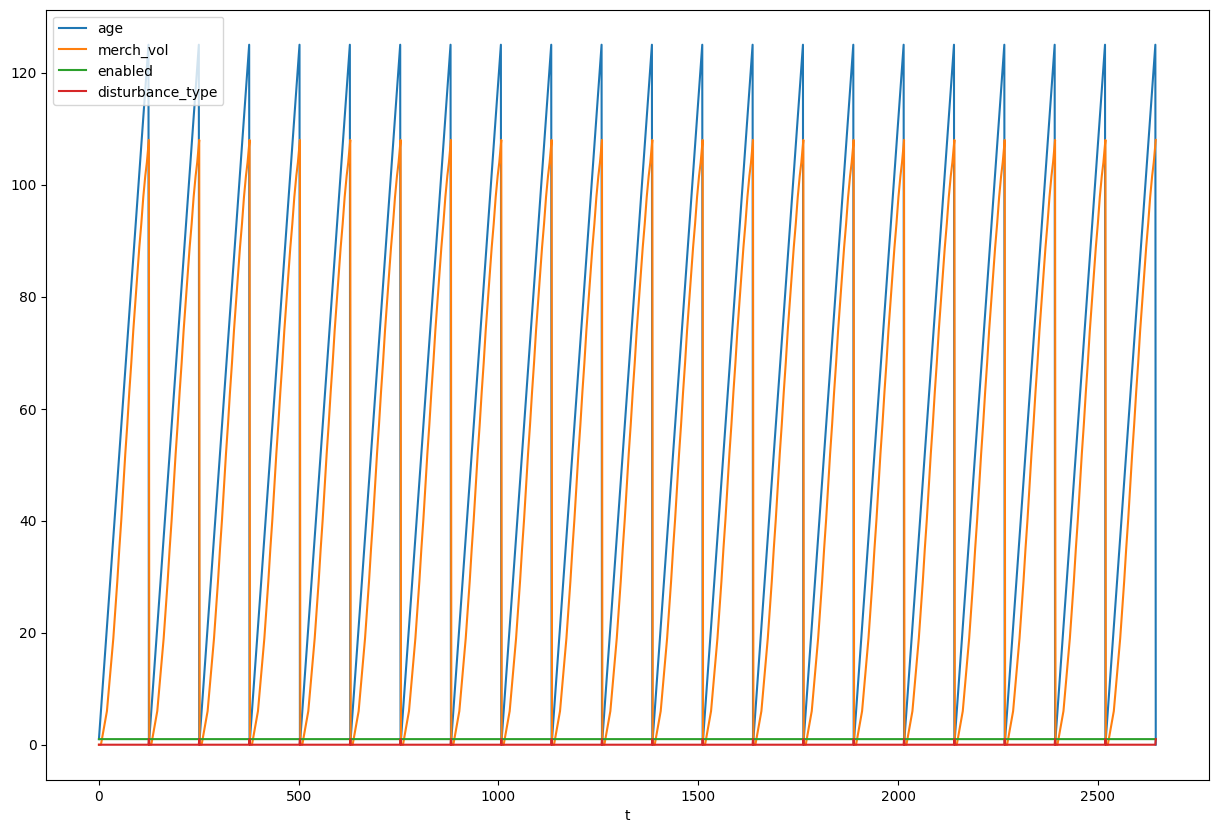

In [11]:
model_state = spinup_debug.state.to_pandas().copy()
model_state.set_index("t").drop(columns=[]).plot(figsize=(15,10))

<Axes: xlabel='t'>

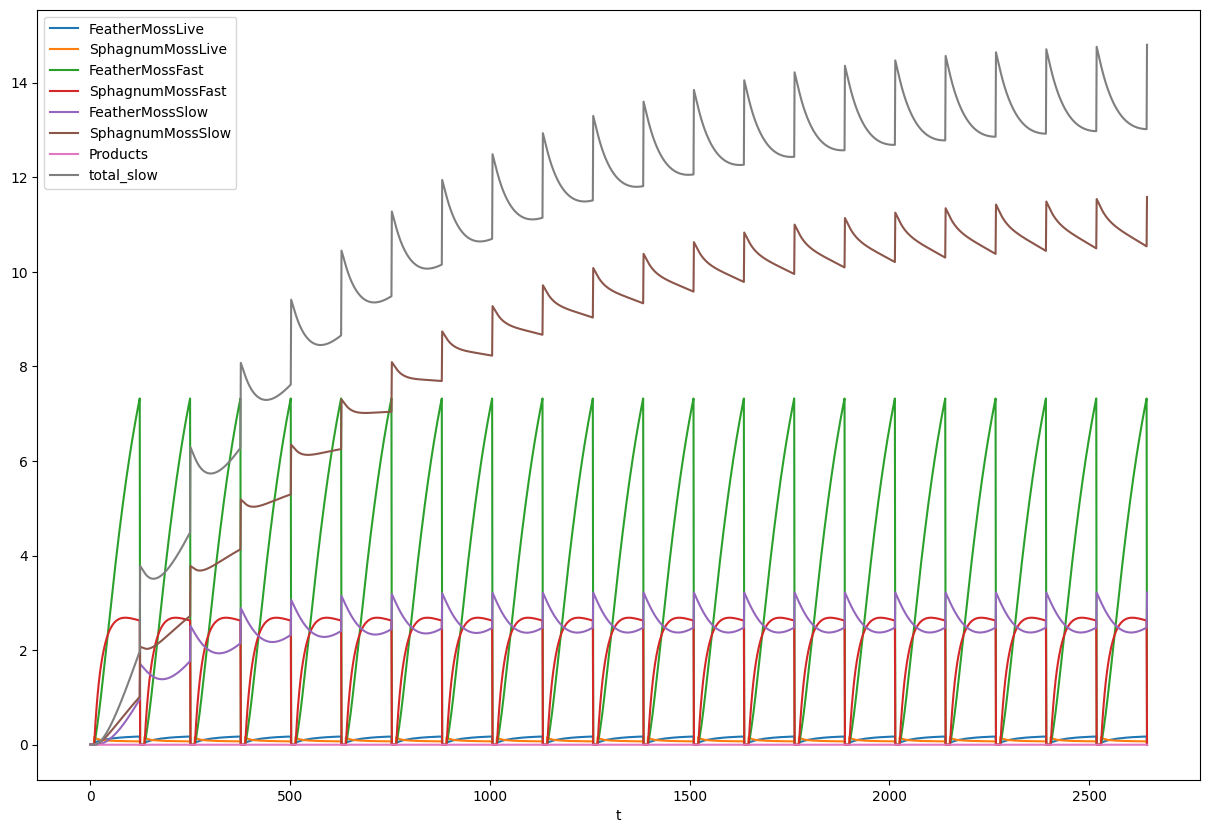

In [12]:
p = spinup_debug.pools.to_pandas().copy()
p["total_slow"] = p[["FeatherMossSlow", "SphagnumMossSlow"]].sum(axis=1)
p.drop(columns=["Input","CO2","CH4","CO"]).set_index("t").plot(figsize=(15,10))

In [13]:
display(p)

,t,Input,FeatherMossLive,SphagnumMossLive,FeatherMossFast,SphagnumMossFast,FeatherMossSlow,SphagnumMossSlow,CO2,CH4,CO,Products,total_slow
0,0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1,1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
2,2,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
3,3,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
4,4,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2641,1.0,0.172381,0.071341,7.192628,2.631956,2.463307,10.552256,477.082866,32.254301,4.897250,0.0,13.015564
2642,2642,1.0,0.172701,0.071255,7.235542,2.629602,2.467948,10.547139,477.286505,32.254301,4.897250,0.0,13.015086
2643,2643,1.0,0.173019,0.071168,7.278003,2.627228,2.472676,10.542019,477.490765,32.254301,4.897250,0.0,13.014695
2644,2644,1.0,0.173335,0.071083,7.320018,2.624834,2.477490,10.536897,477.695639,32.254301,4.897250,0.0,13.014387
